In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers torch accelerate imbalanced-learn seaborn -q

In [ ]:
import torch
print(f"GPU tersedia: {torch.cuda.is_available()}")
print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

GPU tersedia: True
Nama GPU: Tesla T4


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, TrainerCallback
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/SKRIPSI/DATASET_HOSPITAL_LABELED_CASEFOLD.xlsx')

In [ ]:
df.head()

,review,sentiment
0,istri saya sissandra arisi dirawat setelah ope...,positive
1,"tq dr titos, dr suskhan dan suster pelayanan y...",positive
2,suster isti di bagian pendaftaran poliklinik n...,positive
3,"thank you utk dr. titos , dr. tjien ronny & al...",positive
4,terimaksih kepada dokter fery darmawan spog yg...,positive


In [ ]:
df['panjang_review'] = df['review'].apply(lambda x: len(str(x).split()))

print("Statistik Deskriptif Panjang Review:")
print(df['panjang_review'].describe())
print(f"\nRata-rata panjang review : {df['panjang_review'].mean():.2f} kata")
print(f"Review terpendek         : {df['panjang_review'].min()} kata")
print(f"Review terpanjang        : {df['panjang_review'].max()} kata")

Statistik Deskriptif Panjang Review:
count    25295.000000
mean        29.283178
std         29.095332
min          1.000000
25%         15.000000
50%         26.000000
75%         37.000000
max        679.000000
Name: panjang_review, dtype: float64

Rata-rata panjang review : 29.28 kata
Review terpendek         : 1 kata
Review terpanjang        : 679 kata


In [ ]:
df = df.drop('panjang_review', axis=1)

In [ ]:
df.head()

,review,sentiment
0,istri saya sissandra arisi dirawat setelah ope...,positive
1,"tq dr titos, dr suskhan dan suster pelayanan y...",positive
2,suster isti di bagian pendaftaran poliklinik n...,positive
3,"thank you utk dr. titos , dr. tjien ronny & al...",positive
4,terimaksih kepada dokter fery darmawan spog yg...,positive


Distribusi kelas:
sentiment
positive    20259
negative     5036
Name: count, dtype: int64

Total data: 25295

Proporsi kelas:
sentiment
positive    80.090927
negative    19.909073
Name: proportion, dtype: float64


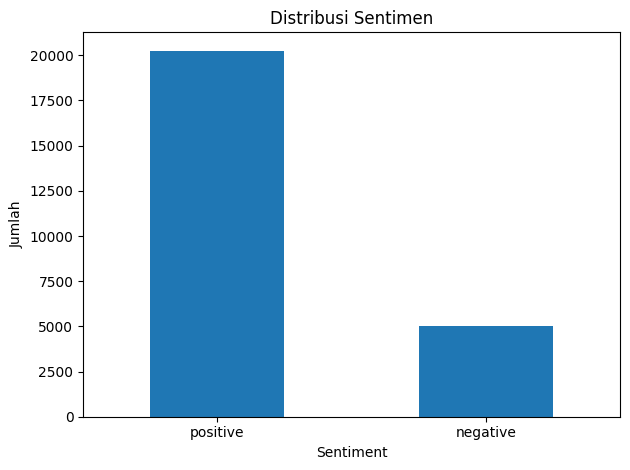

In [ ]:
print("Distribusi kelas:")
print(df['sentiment'].value_counts())
print(f"\nTotal data: {len(df)}")

print("\nProporsi kelas:")
print(df["sentiment"].value_counts(normalize=True) * 100)

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribusi Sentimen")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
def case_folding(text):
    if isinstance(text, str):
        text = text.lower()
        return text
    return text

df['review'] = df['review'].apply(case_folding)

In [ ]:
null_data = df.isna().sum()
print(null_data)

review       0
sentiment    0
dtype: int64


In [ ]:
duplicated_rows = df[df.duplicated()]
print(f"Total duplikat: {len(duplicated_rows)}")

print("\nDuplikat per kelas:")
print(duplicated_rows['sentiment'].value_counts())

Total duplikat: 1375

Duplikat per kelas:
sentiment
positive    1215
negative     160
Name: count, dtype: int64


In [ ]:
df = df.drop_duplicates()
duplicated = df.duplicated().sum()
print(duplicated)

0


In [ ]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()

,review,sentiment
0,istri saya sissandra arisi dirawat setelah ope...,1
1,"tq dr titos, dr suskhan dan suster pelayanan y...",1
2,suster isti di bagian pendaftaran poliklinik n...,1
3,"thank you utk dr. titos , dr. tjien ronny & al...",1
4,terimaksih kepada dokter fery darmawan spog yg...,1


In [ ]:
rus = RandomUnderSampler(random_state=5)
X_resampled, y_resampled = rus.fit_resample(
    df[['review']],
    df['sentiment']
)

df = pd.DataFrame({
    'review': X_resampled['review'],
    'sentiment': y_resampled
})

print("Distribusi setelah undersampling:")
print(df['sentiment'].value_counts())

Distribusi setelah undersampling:
sentiment
0    4876
1    4876
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=5,
    stratify=df['sentiment']
)

In [ ]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_enc = tokenize(X_train)
test_enc = tokenize(X_test)

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_enc, y_train)
test_dataset = SentimentDataset(test_enc, y_test)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [ ]:
class PrintEpochResult(TrainerCallback):
    def __init__(self, test_dataset, train_dataset, y_true, y_train_true):
        self.test_dataset      = test_dataset
        self.train_dataset     = train_dataset
        self.y_true            = y_true
        self.y_train_true      = y_train_true
        self.epoch_reports     = {}
        self.train_acc_history = []
        self.val_acc_history   = []
        self.y_pred_last       = []

    def predict_all(self, dataset, model):
        model.eval()
        preds = []
        with torch.no_grad():
            for i in range(len(dataset)):
                item = dataset[i]
                inputs = {
                    k: v.unsqueeze(0).to(model.device)
                    for k, v in item.items()
                    if k != "labels"
                }
                outputs = model(**inputs)
                pred = torch.argmax(outputs.logits, dim=1).item()
                preds.append(pred)
        return np.array(preds)

    def on_evaluate(self, args, state, control, model=None, metrics=None, **kwargs):
        epoch = int(state.epoch)

        y_pred_val   = self.predict_all(self.test_dataset,  model)
        y_pred_train = self.predict_all(self.train_dataset, model)

        val_acc   = accuracy_score(self.y_true,       y_pred_val)
        train_acc = accuracy_score(self.y_train_true, y_pred_train)

        self.val_acc_history.append(val_acc)
        self.train_acc_history.append(train_acc)
        self.y_pred_last = y_pred_val.tolist()

        report = classification_report(
            self.y_true, y_pred_val,
            target_names=["negative", "positive"],
            output_dict=True
        )

        self.epoch_reports[epoch] = {
            "train_accuracy": train_acc,
            "val_accuracy"  : val_acc,
            "report"        : report
        }

        print(f"\n{'='*60}")
        print(f"Hasil Epoch {epoch}")
        print(f"{'='*60}")
        print(f"Train Accuracy: {train_acc}")
        print(f"Val Accuracy  : {val_acc}\n")
        print("Classification Report:\n")
        print(classification_report(
            self.y_true, y_pred_val,
            target_names=["negative", "positive"]
        ))

In [ ]:
learning_rates  = [2e-5, 1e-5, 1e-6, 1e-7, 5e-5]
num_epochs      = 3
results         = {lr: {} for lr in learning_rates}
loss_data       = {lr: {"train": [], "val": []} for lr in learning_rates}
predictions_all = {}
reports_all     = {}
total_tuning_time = 0  # akumulasi waktu training seluruh LR

print(f"Learning Rates : {learning_rates}")
print(f"Epoch per LR   : {num_epochs}")
print(f"Total percobaan: {len(learning_rates)} model × {num_epochs} epoch")


Learning Rates : [2e-05, 1e-05, 1e-06, 1e-07, 5e-05]
Epoch per LR   : 3
Total percobaan: 5 model × 3 epoch


In [ ]:
print("="*60)
print("  Training Awal — Default Parameter (LR=2e-5)")
print("="*60)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, ignore_mismatched_sizes=True
)

training_args_default = TrainingArguments(
    output_dir="./indobert_results/default",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=num_epochs,
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    load_best_model_at_end=False,
    report_to="none"
)

y_true_train     = np.array([train_dataset[i]["labels"].item() for i in range(len(train_dataset))])
y_true           = np.array([test_dataset[i]["labels"].item()  for i in range(len(test_dataset))])
callback_default = PrintEpochResult(test_dataset, train_dataset, y_true, y_true_train)

trainer_default = Trainer(
    model=model,
    args=training_args_default,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[callback_default]
)

start = time.time()
trainer_default.train()
train_time_default = time.time() - start
total_tuning_time += train_time_default
print(f"Waktu training LR=2e-5: {train_time_default:.2f} detik")

for log in trainer_default.state.log_history:
    if "eval_accuracy" in log:
        ep = int(log["epoch"])
        results[2e-5][ep] = round(log["eval_accuracy"], 4)
    if "loss" in log and "eval_loss" not in log:
        loss_data[2e-5]["train"].append(round(log["loss"], 6))
    if "eval_loss" in log:
        loss_data[2e-5]["val"].append(round(log["eval_loss"], 6))

predictions_all["2e-05"] = {
    "y_true": y_true.tolist(),
    "y_pred": callback_default.y_pred_last
}
reports_all["2e-05"] = callback_default.epoch_reports

with open("indobert_results_tuning.json", "w") as f:
    json.dump({str(k): v for k, v in results.items()}, f)
with open("indobert_loss_data.json", "w") as f:
    json.dump({str(k): v for k, v in loss_data.items()}, f)
with open("indobert_predictions_all.json", "w") as f:
    json.dump(predictions_all, f)
with open("indobert_reports_all.json", "w") as f:
    json.dump(reports_all, f)

print("Default results saved!")


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


  Training Awal — Default Parameter (LR=2e-5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.313253,0.283790,0.925679,0.925397
2,0.160571,0.178267,0.957458,0.957432



Hasil Epoch 1
Train Accuracy: 0.9388539930778106
Val Accuracy  : 0.9256791389031266

Classification Report:

              precision    recall  f1-score   support

    negative       0.88      0.99      0.93       975
    positive       0.99      0.86      0.92       976

    accuracy                           0.93      1951
   macro avg       0.93      0.93      0.93      1951
weighted avg       0.93      0.93      0.93      1951


Hasil Epoch 2
Train Accuracy: 0.9806435072426612
Val Accuracy  : 0.9574577139928242

Classification Report:

              precision    recall  f1-score   support

    negative       0.94      0.98      0.96       975
    positive       0.98      0.93      0.96       976

    accuracy                           0.96      1951
   macro avg       0.96      0.96      0.96      1951
weighted avg       0.96      0.96      0.96      1951


Hasil Epoch 3
Train Accuracy: 0.9915395462120241
Val Accuracy  : 0.9595079446437724

Classification Report:

              pr

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.313253,0.283790,0.925679,0.925397
2,0.160571,0.178267,0.957458,0.957432
3,0.079038,0.206039,0.959508,0.959497


Waktu training LR=2e-5: 914.40 detik
Default results saved!


In [ ]:
for lr in [lr for lr in learning_rates if lr != 2e-5]:
    print(f"\n{'='*60}")
    print(f"  Mulai Training — LR={lr} | Total Epoch={num_epochs}")
    print(f"{'='*60}")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    )

    training_args = TrainingArguments(
        output_dir=f"./indobert_results/lr{lr}",
        learning_rate=lr,
        per_device_train_batch_size=8,
        num_train_epochs=num_epochs,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        load_best_model_at_end=False,
        report_to="none"
    )

    y_true_train = np.array([train_dataset[i]["labels"].item() for i in range(len(train_dataset))])
    y_true       = np.array([test_dataset[i]["labels"].item()  for i in range(len(test_dataset))])
    callback_lr  = PrintEpochResult(test_dataset, train_dataset, y_true, y_true_train)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[callback_lr]
    )

    start = time.time()
    trainer.train()
    train_time_lr = time.time() - start
    total_tuning_time += train_time_lr
    print(f"Waktu training LR={lr}: {train_time_lr:.2f} detik")

    for log in trainer.state.log_history:
        if "eval_accuracy" in log:
            ep = int(log["epoch"])
            results[lr][ep] = round(log["eval_accuracy"], 4)
        if "loss" in log and "eval_loss" not in log:
            loss_data[lr]["train"].append(round(log["loss"], 6))
        if "eval_loss" in log:
            loss_data[lr]["val"].append(round(log["eval_loss"], 6))

    predictions_all[str(lr)] = {
        "y_true": y_true.tolist(),
        "y_pred": callback_lr.y_pred_last
    }
    reports_all[str(lr)] = callback_lr.epoch_reports

    with open("indobert_results_tuning.json", "w") as f:
        json.dump({str(k): v for k, v in results.items()}, f)
    with open("indobert_loss_data.json", "w") as f:
        json.dump({str(k): v for k, v in loss_data.items()}, f)
    with open("indobert_predictions_all.json", "w") as f:
        json.dump(predictions_all, f)
    with open("indobert_reports_all.json", "w") as f:
        json.dump(reports_all, f)

    print(f"LR={lr} saved!")

print(f"\n{'='*60}")
print(f"TOTAL WAKTU TRAINING (KUMULATIF, {len(learning_rates)} LR × {num_epochs} epoch): {total_tuning_time:.2f} detik")
print(f"{'='*60}")

with open("indobert_best.json", "w") as f:
    json.dump({"total_tuning_time": total_tuning_time}, f)


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.



  Mulai Training — LR=1e-05 | Total Epoch=3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.341034,0.300167,0.924141,0.923929
2,0.187935,0.207280,0.950282,0.950259
3,0.106447,0.222465,0.948744,0.948730


...

Waktu training LR=1e-07: 971.79 detik
LR=1e-07 saved!

  Mulai Training — LR=5e-05 | Total Epoch=3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.361400,0.310089,0.920554,0.920221
2,0.227971,0.250081,0.940543,0.940451
3,0.118589,0.225055,0.951307,0.951301



Hasil Epoch 1
Train Accuracy: 0.9223176515831304
Val Accuracy  : 0.920553562275756

Classification Report:

              precision    recall  f1-score   support

    negative       0.87      0.99      0.93       975
    positive       0.98      0.86      0.92       976

    accuracy                           0.92      1951
   macro avg       0.93      0.92      0.92      1951
weighted avg       0.93      0.92      0.92      1951


Hasil Epoch 2
Train Accuracy: 0.9644917318292526
Val Accuracy  : 0.9405433111225013

Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.98      0.94       975
    positive       0.98      0.90      0.94       976

    accuracy                           0.94      1951
   macro avg       0.94      0.94      0.94      1951
weighted avg       0.94      0.94      0.94      1951


Hasil Epoch 3
Train Accuracy: 0.9876938853993078
Val Accuracy  : 0.9513070220399795

Classification Report:

              pre

In [ ]:
df_results = pd.DataFrame.from_dict(results, orient='columns')
df_results.index = [f"Epoch {e}" for e in range(1, num_epochs + 1)]
df_results.columns = [f"LR={lr}" for lr in results.keys()]
df_results.index.name = "Epoch"

print("\nREKAP HASIL HYPERPARAMETER TUNING")
print("="*60)
print(df_results.to_string())


REKAP HASIL HYPERPARAMETER TUNING
         LR=2e-05  LR=1e-05  LR=1e-06  LR=1e-07  LR=5e-05
Epoch                                                    
Epoch 1    0.9257    0.9241    0.8139    0.6920    0.9206
Epoch 2    0.9575    0.9503    0.8570    0.7432    0.9405
Epoch 3    0.9595    0.9487    0.8672    0.7545    0.9513


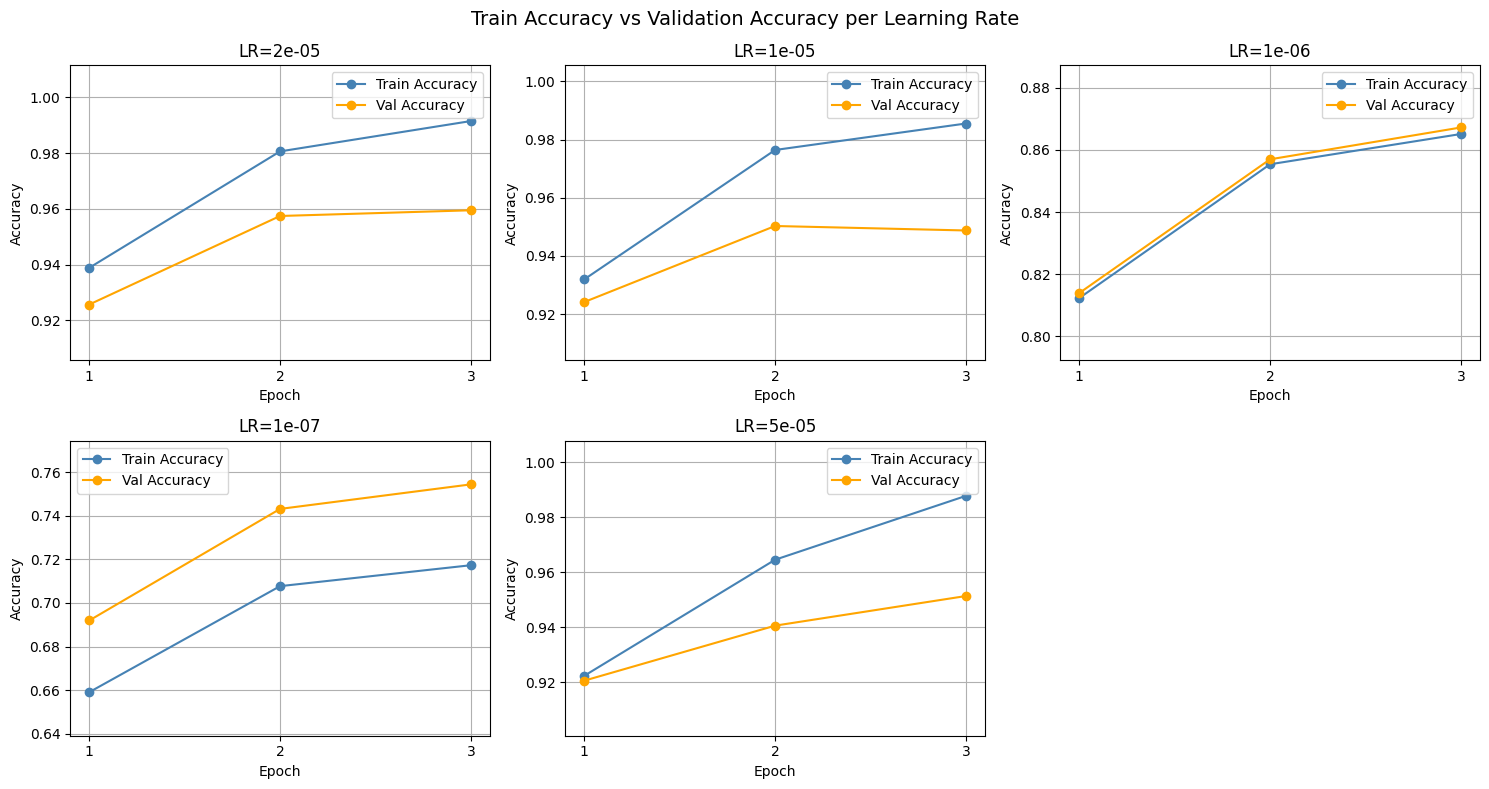

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

all_lr_labels = list(reports_all.keys())

for i, lr_key in enumerate(all_lr_labels):
    ep         = list(range(1, num_epochs + 1))
    train_accs = [reports_all[lr_key][e]["train_accuracy"] for e in range(1, num_epochs + 1)]
    val_accs   = [reports_all[lr_key][e]["val_accuracy"]   for e in range(1, num_epochs + 1)]

    axes[i].plot(ep, train_accs, marker='o', label='Train Accuracy', color='steelblue')
    axes[i].plot(ep, val_accs,   marker='o', label='Val Accuracy',   color='orange')
    axes[i].set_title(f"LR={lr_key}")
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes[i].set_xticks(ep)

    # Skala otomatis mengikuti data, tidak hardcode 0-1
    margin = 0.02
    min_val = min(min(train_accs), min(val_accs)) - margin
    max_val = max(max(train_accs), max(val_accs)) + margin
    axes[i].set_ylim(min_val, max_val)

    axes[i].legend()
    axes[i].grid(True)

axes[5].set_visible(False)

plt.suptitle('Train Accuracy vs Validation Accuracy per Learning Rate', fontsize=14)
plt.tight_layout()
plt.savefig('indobert_accuracy_curves.png', dpi=150)
plt.show()

LR terbaik: 2e-05


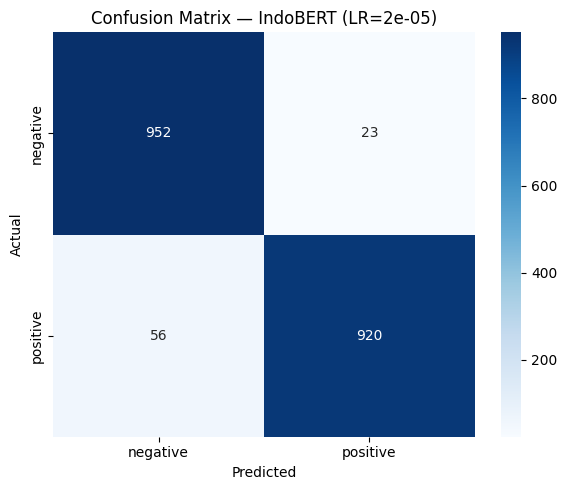

In [ ]:
best_lr_key = max(results, key=lambda lr: max(results[lr].values()))
print(f"LR terbaik: {best_lr_key}")

best_preds = predictions_all[str(best_lr_key)]
y_true_cm  = best_preds["y_true"]
y_pred_cm  = best_preds["y_pred"]

cm = confusion_matrix(y_true_cm, y_pred_cm)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive']
)
plt.title(f'Confusion Matrix — IndoBERT (LR={best_lr_key})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('indobert_confusion_matrix.png', dpi=150)
plt.show()